# MONAI Core Binary Spine / Vertebra Segmentation — 2D UNet Benchmark

This notebook trains a 2D binary segmentation model for frontal spine X-ray images using MONAI Core and PyTorch.

The goal is to segment the annotated spine/vertebra region as a binary mask:

- `0 = background`
- `1 = spine / vertebra region`

The notebook assumes that each X-ray image has a corresponding segmentation mask. If the masks contain multiple vertebra classes, they are converted into binary masks using:

```python
binary_mask = (id_mask > 0).astype(np.uint8)

In [1]:
# ============================================================
# 1) Mount Google Drive
# ============================================================

from google.colab import drive
drive.mount("/content/drive", force_remount=False)

Mounted at /content/drive


In [2]:
# ============================================================
# 2) Install required libraries
# ============================================================

!pip -q install monai nibabel albumentations opencv-python pillow matplotlib pandas tqdm scikit-image

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 39.5 MB/s eta 0:00:00


In [3]:
# ============================================================
# 3) Imports and reproducibility
# ============================================================

from __future__ import annotations

import os
import json
import random
import shutil
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Dict, List, Tuple, Optional

import cv2
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler

import albumentations as A
from albumentations.pytorch import ToTensorV2

import monai
from monai.networks.nets import UNet
from monai.losses import DiceFocalLoss

SEED = 42

def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False

seed_everything(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("MONAI:", monai.__version__)
print("PyTorch:", torch.__version__)
print("DEVICE:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


MONAI: 1.5.2
PyTorch: 2.10.0+cu128
DEVICE: cuda
GPU: NVIDIA A100-SXM4-40GB


In [ ]:
# ============================================================
# 4) Configuration — project paths and experiment settings
# ============================================================

@dataclass
class CFG:
    seed: int = 42

    # Main project paths from your existing notebook.
    PROJECT_BASE: Path = Path(
        " PATH HERE"
    )
    DATASET_ROOT: Path = PROJECT_BASE / "Scoliosis_Dataset"
    YOLO_PROJECT_ROOT: Path = PROJECT_BASE / "yolo_vertebra_seg"
    TRAINING_RUNS_ROOT: Path = YOLO_PROJECT_ROOT / "training_runs"

    # Original image folders.
    NORMAL_DIR: Path = DATASET_ROOT / "Normal"
    SCOLIOSIS_DIR: Path = DATASET_ROOT / "Scoliosis"

    # Original multiclass ID masks.
    ORIGINAL_ID_MASK_DIR: Path = DATASET_ROOT / "LabelMultiClass_ID_PNG"

    # Corrected ID masks from your manual correction workflow.
    CORRECTED_ID_MASK_DIR: Path = DATASET_ROOT / "vertebra_mask_correction" / "outputs" / "LabelMultiClass_ID_PNG_corrected"

    # Existing DeepLabV3+ split CSV. This makes the comparison fair.
    BASELINE_EXPERIMENT_NAME: str = "deeplabv3plus_binary_spine_premask_effb4_seed42_thr06"
    BASELINE_SPLIT_CSV: Path = TRAINING_RUNS_ROOT / BASELINE_EXPERIMENT_NAME / "train_val_test_split.csv"

    # Experiment name for this MONAI run.
    EXPERIMENT_NAME: str = "monai_unet_binary_spine_seed42_img768"
    ARCHITECTURE: str = "MONAI_UNet_2D_binary"

    # Image/training settings.
    IMAGE_SIZE: int = 768
    BATCH_SIZE: int = 2
    NUM_WORKERS: int = 2
    EPOCHS: int = 120
    PATIENCE: int = 25
    LR: float = 2e-4
    WEIGHT_DECAY: float = 1e-5

    # Used only if baseline split CSV does not exist.
    VAL_SIZE: float = 0.15
    TEST_SIZE: float = 0.15

    # Cropping mode. Keep as "full" for fair comparison with current baseline.
    CROP_MODE: str = "full"
    CENTRAL_CROP_WIDTH_FRAC: float = 0.72
    CENTRAL_CROP_HEIGHT_FRAC: float = 1.00

    # Loss/metrics.
    DEFAULT_THRESHOLD: float = 0.5
    THRESHOLDS: Tuple[float, ...] = (0.3, 0.4, 0.5, 0.6, 0.7)

    # Overlay.
    OVERLAY_ALPHA: float = 0.35
    BRIGHT_MASK_RGB: Tuple[int, int, int] = (242, 209, 12)

cfg = CFG()

RUN_DIR = cfg.TRAINING_RUNS_ROOT / cfg.EXPERIMENT_NAME
CHECKPOINT_DIR = RUN_DIR / "checkpoints"
PLOTS_DIR = RUN_DIR / "plots"
SAMPLE_VAL_DIR = RUN_DIR / "sample_validation_overlays"
SAMPLE_TEST_DIR = RUN_DIR / "sample_test_overlays"
INFERENCE_DIR = RUN_DIR / "inference_new_jpegs"

for p in [RUN_DIR, CHECKPOINT_DIR, PLOTS_DIR, SAMPLE_VAL_DIR, SAMPLE_TEST_DIR, INFERENCE_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("PROJECT_BASE          :", cfg.PROJECT_BASE)
print("DATASET_ROOT          :", cfg.DATASET_ROOT, "| exists:", cfg.DATASET_ROOT.exists())
print("NORMAL_DIR            :", cfg.NORMAL_DIR, "| exists:", cfg.NORMAL_DIR.exists())
print("SCOLIOSIS_DIR         :", cfg.SCOLIOSIS_DIR, "| exists:", cfg.SCOLIOSIS_DIR.exists())
print("ORIGINAL_ID_MASK_DIR  :", cfg.ORIGINAL_ID_MASK_DIR, "| exists:", cfg.ORIGINAL_ID_MASK_DIR.exists())
print("CORRECTED_ID_MASK_DIR :", cfg.CORRECTED_ID_MASK_DIR, "| exists:", cfg.CORRECTED_ID_MASK_DIR.exists())
print("BASELINE_SPLIT_CSV    :", cfg.BASELINE_SPLIT_CSV, "| exists:", cfg.BASELINE_SPLIT_CSV.exists())
print("NEW_IMAGES_DIR        :", cfg.NEW_IMAGES_DIR, "| exists:", cfg.NEW_IMAGES_DIR.exists())
print("RUN_DIR               :", RUN_DIR)

In [ ]:
# ============================================================
# 5) Save config
# ============================================================

def path_to_str(obj):
    if isinstance(obj, Path):
        return str(obj)
    if isinstance(obj, tuple):
        return list(obj)
    return obj

config_dict = {k: path_to_str(v) for k, v in asdict(cfg).items()}
config_path = RUN_DIR / "config.json"

with open(config_path, "w", encoding="utf-8") as f:
    json.dump(config_dict, f, indent=2, ensure_ascii=False)

print("Saved config:", config_path)

In [6]:
# ============================================================
# 6) Path helpers and image/mask discovery
# ============================================================

IMAGE_EXTS = [".jpg", ".jpeg", ".png", ".tif", ".tiff", ".bmp"]
ALLOWED_IDS = set(range(18))  # 0..17

def strip_labelmulti_prefix(stem: str) -> str:
    return stem[len("LabelMulti_"):] if stem.startswith("LabelMulti_") else stem

def ensure_labelmulti_prefix(stem: str) -> str:
    return stem if stem.startswith("LabelMulti_") else f"LabelMulti_{stem}"

def find_image_for_mask_stem(mask_stem: str) -> Optional[Path]:
    image_stem = strip_labelmulti_prefix(mask_stem)
    candidate_dirs = [cfg.NORMAL_DIR, cfg.SCOLIOSIS_DIR]

    for d in candidate_dirs:
        for ext in IMAGE_EXTS:
            p = d / f"{image_stem}{ext}"
            if p.exists():
                return p

    for d in candidate_dirs:
        for ext in IMAGE_EXTS:
            p = d / f"{mask_stem}{ext}"
            if p.exists():
                return p

    return None

def corrected_or_original_mask(mask_path: Path) -> Tuple[Path, str]:
    corrected_candidate = cfg.CORRECTED_ID_MASK_DIR / mask_path.name
    if corrected_candidate.exists():
        return corrected_candidate, "corrected"
    return mask_path, "original"

def discover_pairs_from_masks() -> pd.DataFrame:
    rows = []
    original_masks = sorted(cfg.ORIGINAL_ID_MASK_DIR.glob("*.png"))

    for original_mask_path in tqdm(original_masks, desc="Discovering image/mask pairs"):
        mask_stem = original_mask_path.stem
        image_path = find_image_for_mask_stem(mask_stem)
        if image_path is None:
            rows.append({
                "stem": mask_stem,
                "image_path": None,
                "mask_path": str(original_mask_path),
                "original_mask_path": str(original_mask_path),
                "mask_source": "missing_image",
                "usable": False,
                "reason": "image_not_found",
            })
            continue

        priority_mask_path, mask_source = corrected_or_original_mask(original_mask_path)

        rows.append({
            "stem": mask_stem,
            "image_path": str(image_path),
            "mask_path": str(priority_mask_path),
            "original_mask_path": str(original_mask_path),
            "mask_source": mask_source,
            "usable": True,
            "reason": "",
        })

    return pd.DataFrame(rows)

pairs_df = discover_pairs_from_masks()
print("Total discovered rows:", len(pairs_df))
display(pairs_df.head())
print(pairs_df["mask_source"].value_counts(dropna=False))

Discovering image/mask pairs:   0%|          | 0/249 [00:00<?, ?it/s]

Total discovered rows: 249


,stem,image_path,mask_path,original_mask_path,mask_source,usable,reason
0,LabelMulti_N_1,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,original,True,
1,LabelMulti_N_10,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,original,True,
2,LabelMulti_N_11,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,original,True,
3,LabelMulti_N_12,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,original,True,
4,LabelMulti_N_13,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,original,True,


mask_source
corrected        146
original         102
missing_image      1
Name: count, dtype: int64


In [8]:
# ============================================================
# 7) Validation helpers
# ============================================================

import time

def safe_open_pil(path: Path, mode: str | None = None, retries: int = 3, sleep_seconds: float = 1.0) -> Image.Image:
    """
    Opens an image with small retries.

    This protects the notebook from temporary Google Drive disconnects such as:
    OSError: [Errno 107] Transport endpoint is not connected
    """
    last_error = None

    for attempt in range(1, retries + 1):
        try:
            img = Image.open(path)
            img.load()  # Force actual read now, while file handle is open.
            if mode is not None:
                img = img.convert(mode)
            return img
        except OSError as e:
            last_error = e
            print(f"[read retry {attempt}/{retries}] {path.name}: {e}")
            time.sleep(sleep_seconds)

    raise last_error


def read_image_rgb(path: Path) -> np.ndarray:
    img = safe_open_pil(path, mode="RGB")
    return np.array(img, dtype=np.uint8)


def read_id_mask(path: Path) -> np.ndarray:
    mask = safe_open_pil(path, mode=None)
    arr = np.array(mask)

    if arr.ndim == 3:
        # Correct ID masks should be single-channel, but if accidentally RGB,
        # use first channel only, matching your existing workflow.
        arr = arr[:, :, 0]

    return arr.astype(np.uint8)


def validate_one(row) -> Dict:
    if not row["usable"]:
        return {"usable": False, "reason": row["reason"]}

    image_path = Path(row["image_path"])
    mask_path = Path(row["mask_path"])

    if not image_path.exists():
        return {"usable": False, "reason": "image_path_missing"}
    if not mask_path.exists():
        return {"usable": False, "reason": "mask_path_missing"}

    try:
        img = read_image_rgb(image_path)
        mask = read_id_mask(mask_path)
    except OSError as e:
        return {
            "usable": False,
            "reason": f"read_error_{type(e).__name__}: {str(e)[:160]}",
            "image_h": None,
            "image_w": None,
            "mask_h": None,
            "mask_w": None,
            "unique_ids": "",
            "foreground_pixels": None,
        }

    image_h, image_w = img.shape[:2]
    mask_h, mask_w = mask.shape[:2]
    unique_ids = sorted(np.unique(mask).astype(int).tolist())
    unexpected_ids = [x for x in unique_ids if x not in ALLOWED_IDS]

    if (image_h, image_w) != (mask_h, mask_w):
        return {
            "usable": False,
            "reason": f"size_mismatch_image_{image_w}x{image_h}_mask_{mask_w}x{mask_h}",
            "image_h": image_h,
            "image_w": image_w,
            "mask_h": mask_h,
            "mask_w": mask_w,
            "unique_ids": " ".join(map(str, unique_ids)),
            "foreground_pixels": int((mask > 0).sum()),
        }

    if unexpected_ids:
        return {
            "usable": False,
            "reason": f"unexpected_ids_{unexpected_ids}",
            "image_h": image_h,
            "image_w": image_w,
            "mask_h": mask_h,
            "mask_w": mask_w,
            "unique_ids": " ".join(map(str, unique_ids)),
            "foreground_pixels": int((mask > 0).sum()),
        }

    binary = (mask > 0).astype(np.uint8)
    if int(binary.sum()) == 0:
        return {
            "usable": False,
            "reason": "empty_foreground_mask",
            "image_h": image_h,
            "image_w": image_w,
            "mask_h": mask_h,
            "mask_w": mask_w,
            "unique_ids": " ".join(map(str, unique_ids)),
            "foreground_pixels": int(binary.sum()),
        }

    return {
        "usable": True,
        "reason": "",
        "image_h": image_h,
        "image_w": image_w,
        "mask_h": mask_h,
        "mask_w": mask_w,
        "unique_ids": " ".join(map(str, unique_ids)),
        "foreground_pixels": int(binary.sum()),
    }


validation_rows = []
for _, row in tqdm(pairs_df.iterrows(), total=len(pairs_df), desc="Validating pairs"):
    validation_rows.append(validate_one(row))

validation_df = pd.DataFrame(validation_rows)
pairs_validated_df = pd.concat([pairs_df.reset_index(drop=True), validation_df.add_prefix("check_")], axis=1)

# Final usable flag must pass discovery and validation.
pairs_validated_df["final_usable"] = pairs_validated_df["usable"] & pairs_validated_df["check_usable"].fillna(False)

pairs_csv_path = RUN_DIR / "all_pairs_validation.csv"
usable_csv_path = RUN_DIR / "usable_pairs.csv"
pairs_validated_df.to_csv(pairs_csv_path, index=False)
usable_df = pairs_validated_df[pairs_validated_df["final_usable"]].copy().reset_index(drop=True)
usable_df.to_csv(usable_csv_path, index=False)

print("All pairs:", len(pairs_validated_df))
print("Usable pairs:", len(usable_df))
print("Saved:", pairs_csv_path)
print("Saved:", usable_csv_path)
print("Validation reasons:")
print(pairs_validated_df["check_reason"].value_counts(dropna=False).head(20))
display(usable_df[["stem", "image_path", "mask_path", "mask_source", "check_unique_ids", "check_foreground_pixels"]].head())

Validating pairs:   0%|          | 0/249 [00:00<?, ?it/s]

All pairs: 249
Usable pairs: 248
Saved: /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/training_runs/monai_unet_binary_spine_seed42_img768/all_pairs_validation.csv
Saved: /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/training_runs/monai_unet_binary_spine_seed42_img768/usable_pairs.csv
Validation reasons:
check_reason
                   248
image_not_found      1
Name: count, dtype: int64


,stem,image_path,mask_path,mask_source,check_unique_ids,check_foreground_pixels
0,LabelMulti_N_1,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,original,0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17,44373.0
1,LabelMulti_N_10,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,original,0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17,28945.0
2,LabelMulti_N_11,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,original,0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17,19436.0
3,LabelMulti_N_12,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,original,0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17,35350.0
4,LabelMulti_N_13,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...,original,0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17,22663.0


In [9]:
# ============================================================
# 8) Train/val/test split — reuse baseline split if available
# ============================================================

assert len(usable_df) > 0, "No usable image/mask pairs found."

def build_split_from_existing_csv(usable_df: pd.DataFrame, split_csv: Path) -> Optional[pd.DataFrame]:
    if not split_csv.exists():
        return None

    old_split = pd.read_csv(split_csv)
    if "stem" not in old_split.columns or "split" not in old_split.columns:
        print("Existing split CSV found, but it lacks stem/split columns. Ignoring it.")
        return None

    split_map = dict(zip(old_split["stem"].astype(str), old_split["split"].astype(str)))
    df = usable_df.copy()
    df["split"] = df["stem"].astype(str).map(split_map)

    missing = df["split"].isna().sum()
    if missing > 0:
        print(f"Existing split did not cover {missing} usable rows. Ignoring it for safety.")
        return None

    return df.reset_index(drop=True)

split_df = build_split_from_existing_csv(usable_df, cfg.BASELINE_SPLIT_CSV)

if split_df is None:
    print("Creating a new seed-42 split because the baseline split CSV was not available/usable.")
    rng = np.random.default_rng(cfg.seed)
    indices = np.arange(len(usable_df))
    rng.shuffle(indices)

    n_total = len(indices)
    n_test = int(round(n_total * cfg.TEST_SIZE))
    n_val = int(round(n_total * cfg.VAL_SIZE))
    n_train = n_total - n_val - n_test

    train_idx = indices[:n_train]
    val_idx = indices[n_train:n_train + n_val]
    test_idx = indices[n_train + n_val:]

    split_df = pd.concat([
        usable_df.iloc[train_idx].assign(split="train"),
        usable_df.iloc[val_idx].assign(split="val"),
        usable_df.iloc[test_idx].assign(split="test"),
    ], ignore_index=True)
else:
    print("Reusing baseline split CSV for fair comparison:")
    print(cfg.BASELINE_SPLIT_CSV)

train_df = split_df[split_df["split"] == "train"].reset_index(drop=True)
val_df = split_df[split_df["split"] == "val"].reset_index(drop=True)
test_df = split_df[split_df["split"] == "test"].reset_index(drop=True)

split_csv_path = RUN_DIR / "train_val_test_split.csv"
split_df.to_csv(split_csv_path, index=False)

print("Train:", len(train_df))
print("Val  :", len(val_df))
print("Test :", len(test_df))
print("Saved split CSV:", split_csv_path)
display(split_df[["stem", "split", "mask_source", "image_path", "mask_path"]].head())

Reusing baseline split CSV for fair comparison:
/content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/training_runs/deeplabv3plus_binary_spine_premask_effb4_seed42_thr06/train_val_test_split.csv
Train: 174
Val  : 37
Test : 37
Saved split CSV: /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/training_runs/monai_unet_binary_spine_seed42_img768/train_val_test_split.csv


,stem,split,mask_source,image_path,mask_path
0,LabelMulti_N_1,train,original,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...
1,LabelMulti_N_10,val,original,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...
2,LabelMulti_N_11,train,original,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...
3,LabelMulti_N_12,train,original,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...
4,LabelMulti_N_13,train,original,/content/drive/MyDrive/Artificial Intelligence...,/content/drive/MyDrive/Artificial Intelligence...


In [10]:
# ============================================================
# 9) Safe central crop helpers + paste-back metadata
# ============================================================

def central_crop_box(h: int, w: int, width_frac: float, height_frac: float) -> Tuple[int, int, int, int]:
    crop_w = int(round(w * width_frac))
    crop_h = int(round(h * height_frac))
    crop_w = max(1, min(crop_w, w))
    crop_h = max(1, min(crop_h, h))
    x0 = max(0, (w - crop_w) // 2)
    y0 = max(0, (h - crop_h) // 2)
    x1 = x0 + crop_w
    y1 = y0 + crop_h
    return x0, y0, x1, y1

def apply_crop_if_needed(image: np.ndarray, mask: Optional[np.ndarray] = None):
    h, w = image.shape[:2]

    meta = {
        "orig_h": h,
        "orig_w": w,
        "crop_mode": cfg.CROP_MODE,
        "x0": 0,
        "y0": 0,
        "x1": w,
        "y1": h,
    }

    if cfg.CROP_MODE == "central":
        x0, y0, x1, y1 = central_crop_box(
            h=h,
            w=w,
            width_frac=cfg.CENTRAL_CROP_WIDTH_FRAC,
            height_frac=cfg.CENTRAL_CROP_HEIGHT_FRAC,
        )
        meta.update({"x0": x0, "y0": y0, "x1": x1, "y1": y1})
        image = image[y0:y1, x0:x1]
        if mask is not None:
            mask = mask[y0:y1, x0:x1]

    return image, mask, meta

def paste_crop_prediction_back(pred_crop: np.ndarray, meta: Dict) -> np.ndarray:
    full = np.zeros((meta["orig_h"], meta["orig_w"]), dtype=pred_crop.dtype)
    x0, y0, x1, y1 = meta["x0"], meta["y0"], meta["x1"], meta["y1"]
    full[y0:y1, x0:x1] = pred_crop
    return full

In [11]:
# ============================================================
# 10) Albumentations transforms
# ============================================================

# MONAI provides the model/loss. Albumentations is kept here because it handles
# JPG/PNG 2D augmentation cleanly and matches your existing notebook style.

def get_train_transforms():
    return A.Compose([
        A.LongestMaxSize(max_size=cfg.IMAGE_SIZE, interpolation=cv2.INTER_LINEAR),
        A.PadIfNeeded(
            min_height=cfg.IMAGE_SIZE,
            min_width=cfg.IMAGE_SIZE,
            border_mode=cv2.BORDER_CONSTANT,
            fill=0,
            fill_mask=0,
        ),
        A.HorizontalFlip(p=0.5),
        A.ShiftScaleRotate(
            shift_limit=0.03,
            scale_limit=0.08,
            rotate_limit=4,
            interpolation=cv2.INTER_LINEAR,
            border_mode=cv2.BORDER_CONSTANT,
            value=0,
            mask_value=0,
            p=0.45,
        ),
        A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.35),
        A.GaussNoise(var_limit=(5.0, 25.0), p=0.15),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ])

def get_valid_transforms():
    return A.Compose([
        A.LongestMaxSize(max_size=cfg.IMAGE_SIZE, interpolation=cv2.INTER_LINEAR),
        A.PadIfNeeded(
            min_height=cfg.IMAGE_SIZE,
            min_width=cfg.IMAGE_SIZE,
            border_mode=cv2.BORDER_CONSTANT,
            fill=0,
            fill_mask=0,
        ),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ])

In [12]:
# ============================================================
# 11) Dataset and dataloaders
# ============================================================

class BinarySpineDataset(Dataset):
    def __init__(self, df: pd.DataFrame, transforms=None):
        self.df = df.reset_index(drop=True)
        self.transforms = transforms

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_path = Path(row["image_path"])
        mask_path = Path(row["mask_path"])

        image = read_image_rgb(image_path)
        id_mask = read_id_mask(mask_path)
        binary_mask = (id_mask > 0).astype(np.uint8)

        image, binary_mask, crop_meta = apply_crop_if_needed(image, binary_mask)

        if self.transforms is not None:
            transformed = self.transforms(image=image, mask=binary_mask)
            image_t = transformed["image"]
            mask_t = transformed["mask"]
        else:
            image_t = torch.from_numpy(image.transpose(2, 0, 1)).float() / 255.0
            mask_t = torch.from_numpy(binary_mask).long()

        # BCE/Dice-style losses expect [B, 1, H, W] float masks.
        if mask_t.ndim == 2:
            mask_t = mask_t.unsqueeze(0)
        mask_t = mask_t.float()

        return {
            "image": image_t.float(),
            "mask": mask_t,
            "stem": row["stem"],
            "image_path": str(image_path),
            "mask_path": str(mask_path),
        }

train_ds = BinarySpineDataset(train_df, transforms=get_train_transforms())
val_ds = BinarySpineDataset(val_df, transforms=get_valid_transforms())
test_ds = BinarySpineDataset(test_df, transforms=get_valid_transforms())

train_loader = DataLoader(
    train_ds,
    batch_size=cfg.BATCH_SIZE,
    shuffle=True,
    num_workers=cfg.NUM_WORKERS,
    pin_memory=True,
    drop_last=False,
)
val_loader = DataLoader(
    val_ds,
    batch_size=cfg.BATCH_SIZE,
    shuffle=False,
    num_workers=cfg.NUM_WORKERS,
    pin_memory=True,
    drop_last=False,
)
test_loader = DataLoader(
    test_ds,
    batch_size=cfg.BATCH_SIZE,
    shuffle=False,
    num_workers=cfg.NUM_WORKERS,
    pin_memory=True,
    drop_last=False,
)

batch = next(iter(train_loader))
print(batch["image"].shape, batch["mask"].shape)
print(batch["image"].dtype, batch["mask"].dtype)
print("Mask unique values in first batch:", torch.unique(batch["mask"]))

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_2596/3902190793.py:19: UserWarning: Argument(s) 'value, mask_value' are not valid for transform ShiftScaleRotate
  A.ShiftScaleRotate(
/tmp/ipykernel_2596/3902190793.py:30: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(5.0, 25.0), p=0.15),


torch.Size([2, 3, 768, 768]) torch.Size([2, 1, 768, 768])
torch.float32 torch.float32
Mask unique values in first batch: tensor([0., 1.])


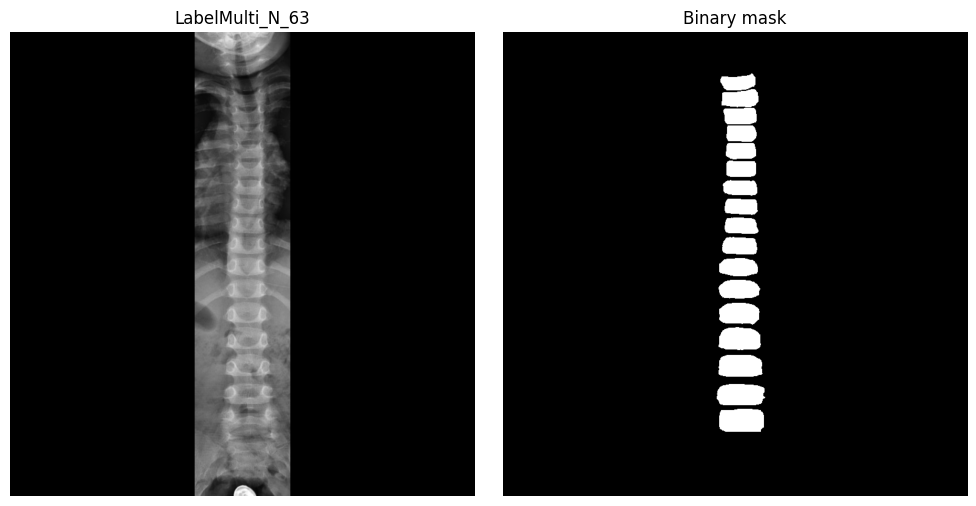

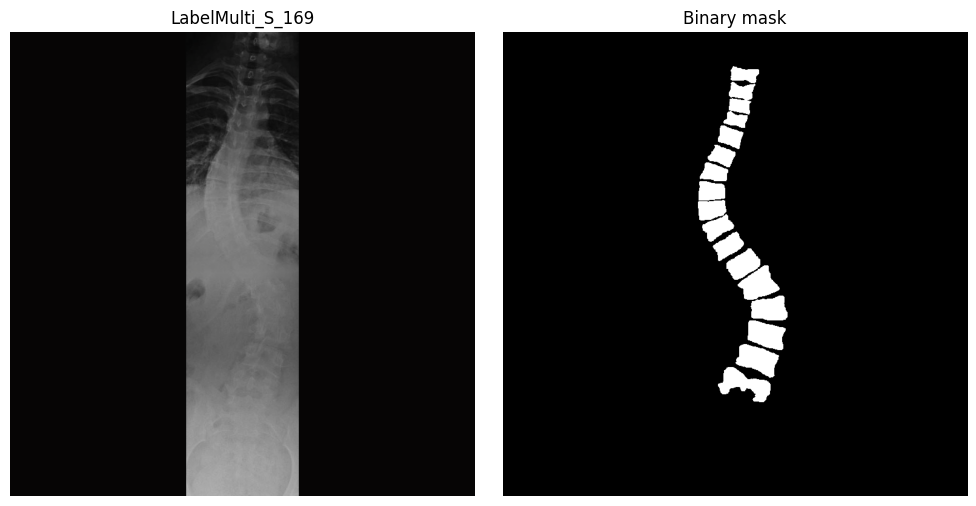

In [13]:
# ============================================================
# 12) Visual sanity check
# ============================================================

def show_batch(batch, max_items=3):
    images = batch["image"][:max_items]
    masks = batch["mask"][:max_items]

    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    for i in range(len(images)):
        img = images[i].cpu() * std + mean
        img = img.clamp(0, 1).permute(1, 2, 0).numpy()
        mask = masks[i, 0].cpu().numpy()

        fig, axes = plt.subplots(1, 2, figsize=(10, 5))
        axes[0].imshow(img)
        axes[0].set_title(batch["stem"][i])
        axes[0].axis("off")
        axes[1].imshow(mask, cmap="gray")
        axes[1].set_title("Binary mask")
        axes[1].axis("off")
        plt.tight_layout()
        plt.show()

show_batch(batch, max_items=3)

In [14]:
# ============================================================
# 13) MONAI 2D UNet model, loss, optimizer
# ============================================================

model = UNet(
    spatial_dims=2,
    in_channels=3,
    out_channels=1,
    channels=(32, 64, 128, 256, 512),
    strides=(2, 2, 2, 2),
    num_res_units=2,
    norm="BATCH",
    dropout=0.05,
).to(DEVICE)

loss_fn = DiceFocalLoss(
    sigmoid=True,
    squared_pred=True,
    lambda_dice=0.7,
    lambda_focal=0.3,
)

optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.LR, weight_decay=cfg.WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=6,
    min_lr=1e-6,
)
scaler = GradScaler("cuda", enabled=(DEVICE.type == "cuda"))

n_params = sum(p.numel() for p in model.parameters())
print("Model:", cfg.ARCHITECTURE)
print("Parameters:", f"{n_params:,}")

Model: MONAI_UNet_2D_binary
Parameters: 6,500,734


In [15]:
# ============================================================
# 14) Metrics and epoch loops
# ============================================================

EPS = 1e-7

def compute_metrics_from_logits(logits: torch.Tensor, masks: torch.Tensor, threshold: float = 0.5) -> Dict[str, float]:
    probs = torch.sigmoid(logits)
    preds = (probs >= threshold).float()
    targets = masks.float()

    dims = (1, 2, 3)
    tp = (preds * targets).sum(dim=dims)
    fp = (preds * (1 - targets)).sum(dim=dims)
    fn = ((1 - preds) * targets).sum(dim=dims)

    dice = (2 * tp + EPS) / (2 * tp + fp + fn + EPS)
    iou = (tp + EPS) / (tp + fp + fn + EPS)
    precision = (tp + EPS) / (tp + fp + EPS)
    recall = (tp + EPS) / (tp + fn + EPS)

    return {
        "dice": float(dice.mean().detach().cpu()),
        "iou": float(iou.mean().detach().cpu()),
        "precision": float(precision.mean().detach().cpu()),
        "recall": float(recall.mean().detach().cpu()),
    }

def train_one_epoch(model, loader):
    model.train()
    running_loss = 0.0
    metric_sums = {"dice": 0.0, "iou": 0.0, "precision": 0.0, "recall": 0.0}
    n_batches = 0

    for batch in tqdm(loader, desc="train", leave=False):
        images = batch["image"].to(DEVICE, non_blocking=True)
        masks = batch["mask"].to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with autocast("cuda", enabled=(DEVICE.type == "cuda")):
            logits = model(images)
            loss = loss_fn(logits, masks)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        running_loss += float(loss.item())
        metrics = compute_metrics_from_logits(logits.detach(), masks, threshold=cfg.DEFAULT_THRESHOLD)
        for k in metric_sums:
            metric_sums[k] += metrics[k]
        n_batches += 1

    out = {f"train_{k}": v / max(1, n_batches) for k, v in metric_sums.items()}
    out["train_loss"] = running_loss / max(1, n_batches)
    return out

@torch.no_grad()
def validate_one_epoch(model, loader, split_name="val", threshold: float = 0.5):
    model.eval()
    running_loss = 0.0
    metric_sums = {"dice": 0.0, "iou": 0.0, "precision": 0.0, "recall": 0.0}
    n_batches = 0

    for batch in tqdm(loader, desc=split_name, leave=False):
        images = batch["image"].to(DEVICE, non_blocking=True)
        masks = batch["mask"].to(DEVICE, non_blocking=True)

        with autocast("cuda", enabled=(DEVICE.type == "cuda")):
            logits = model(images)
            loss = loss_fn(logits, masks)

        running_loss += float(loss.item())
        metrics = compute_metrics_from_logits(logits, masks, threshold=threshold)
        for k in metric_sums:
            metric_sums[k] += metrics[k]
        n_batches += 1

    out = {f"{split_name}_{k}": v / max(1, n_batches) for k, v in metric_sums.items()}
    out[f"{split_name}_loss"] = running_loss / max(1, n_batches)
    out[f"{split_name}_threshold"] = threshold
    return out

In [17]:
# ============================================================
# 15) Train with early stopping
# ============================================================

best_val_dice = -1.0
best_epoch = -1
epochs_without_improvement = 0
history = []

best_ckpt_path = CHECKPOINT_DIR / "best_model.pth"
last_ckpt_path = CHECKPOINT_DIR / "last_model.pth"
metrics_csv_path = RUN_DIR / "metrics.csv"

for epoch in range(1, cfg.EPOCHS + 1):
    print(f"Epoch {epoch}/{cfg.EPOCHS}")

    train_metrics = train_one_epoch(model, train_loader)
    val_metrics = validate_one_epoch(model, val_loader, split_name="val", threshold=cfg.DEFAULT_THRESHOLD)

    row = {
        "epoch": epoch,
        "lr": optimizer.param_groups[0]["lr"],
        **train_metrics,
        **val_metrics,
    }
    history.append(row)

    val_dice = val_metrics["val_dice"]
    scheduler.step(val_dice)

    pd.DataFrame(history).to_csv(metrics_csv_path, index=False)

    save_obj = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "cfg": config_dict,
        "metrics": row,
    }
    torch.save(save_obj, last_ckpt_path)

    improved = val_dice > best_val_dice
    if improved:
        best_val_dice = val_dice
        best_epoch = epoch
        epochs_without_improvement = 0
        torch.save(save_obj, best_ckpt_path)
        print(f"Saved new best model: val_dice={best_val_dice:.4f}")
    else:
        epochs_without_improvement += 1

    print(json.dumps(row, indent=2))

    if epochs_without_improvement >= cfg.PATIENCE:
        print(f"Early stopping at epoch {epoch}. Best epoch: {best_epoch}, best val Dice: {best_val_dice:.4f}")
        break

print("Best checkpoint:", best_ckpt_path)
print("Last checkpoint:", last_ckpt_path)
print("Metrics CSV:", metrics_csv_path)

Epoch 1/120


train:   0%|          | 0/87 [00:00<?, ?it/s]

val:   0%|          | 0/19 [00:00<?, ?it/s]

Saved new best model: val_dice=0.4821
{
  "epoch": 1,
  "lr": 0.0002,
  "train_dice": 0.33182060041989403,
  "train_iou": 0.2104369660561112,
  "train_precision": 0.2226210183667383,
  "train_recall": 0.8244368211291302,
  "train_loss": 0.6268028651160755,
  "val_dice": 0.4821161235633649,
  "val_iou": 0.32830468447584854,
  "val_precision": 0.39924060043535736,
  "val_recall": 0.6891670227050781,
  "val_loss": 0.5950525089314109,
  "val_threshold": 0.5
}
Epoch 2/120


train:   0%|          | 0/87 [00:00<?, ?it/s]

...

val:   0%|          | 0/19 [00:00<?, ?it/s]

{
  "epoch": 119,
  "lr": 6.25e-06,
  "train_dice": 0.916525374198782,
  "train_iou": 0.8469491032348282,
  "train_precision": 0.9065619549532046,
  "train_recall": 0.9281280849171781,
  "train_loss": 0.04806804738339336,
  "val_dice": 0.8968200181659899,
  "val_iou": 0.813760286883304,
  "val_precision": 0.8926739253495869,
  "val_recall": 0.9024200564936588,
  "val_loss": 0.06058441827955999,
  "val_threshold": 0.5
}
Epoch 120/120


train:   0%|          | 0/87 [00:00<?, ?it/s]

val:   0%|          | 0/19 [00:00<?, ?it/s]

{
  "epoch": 120,
  "lr": 6.25e-06,
  "train_dice": 0.9144828374358429,
  "train_iou": 0.8440131079191449,
  "train_precision": 0.9046500496480657,
  "train_recall": 0.9263191147782337,
  "train_loss": 0.04927914799458679,
  "val_dice": 0.8962178889073824,
  "val_iou": 0.8127804712245339,
  "val_precision": 0.8977436046851309,
  "val_recall": 0.8961020049295927,
  "val_loss": 0.06106049194931984,
  "val_threshold": 0.5
}
Best checkpoint: /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/training_runs/monai_unet_binary_spine_seed42_img768/checkpoints/best_model.pth
Last checkpoint: /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/training_runs/monai_unet_binary_spine_seed42_img768/checkpoints/last_model.pth
Metrics CSV: /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluc

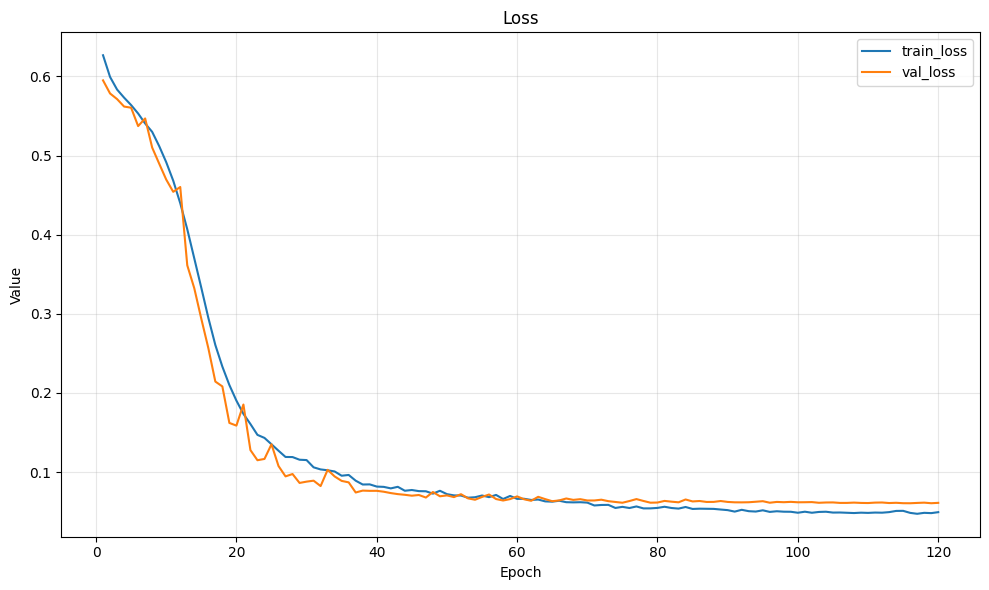

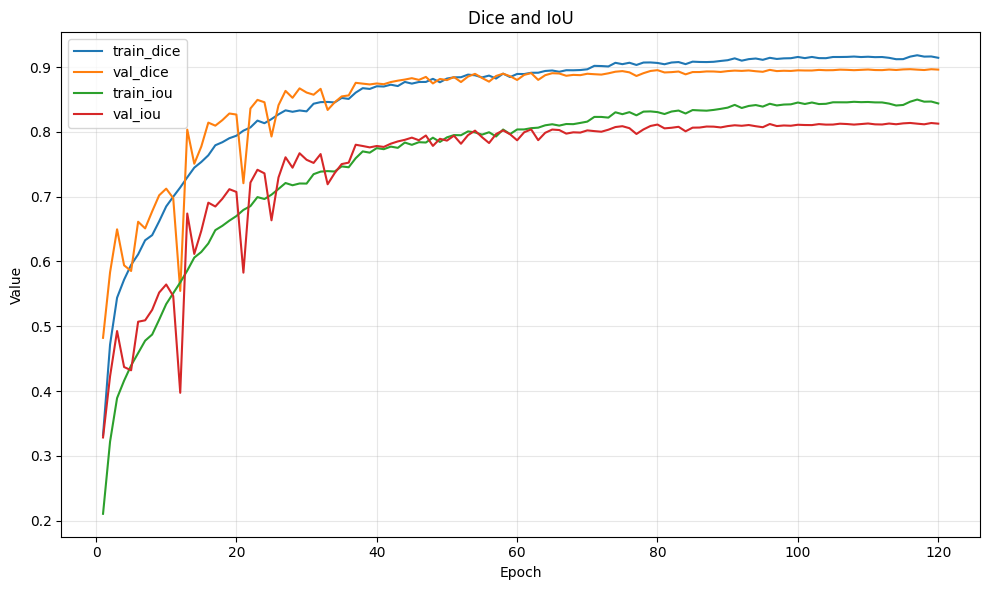

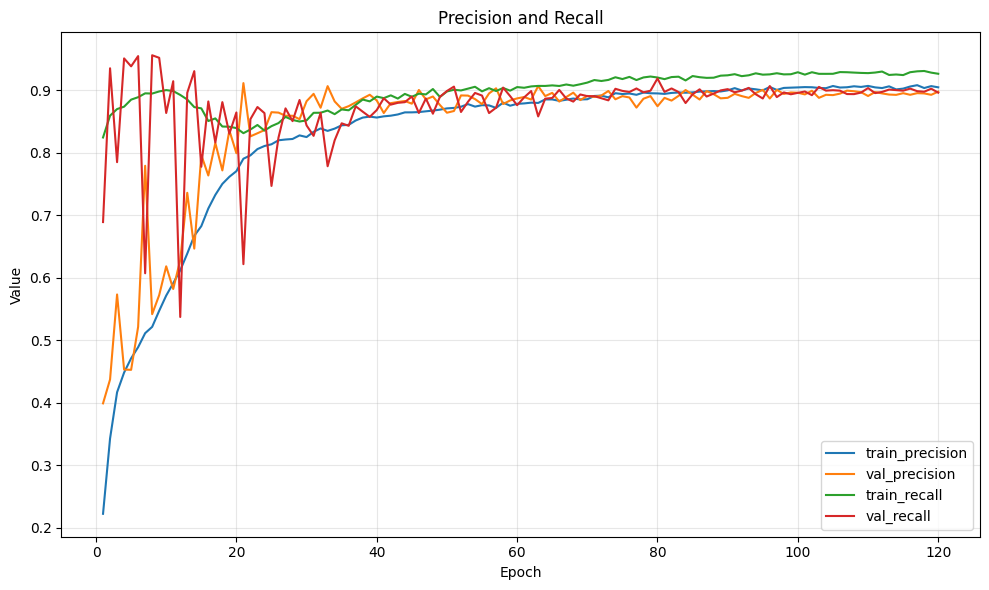

In [18]:
# ============================================================
# 16) Plot loss and metrics
# ============================================================

history_df = pd.read_csv(metrics_csv_path)

def save_metric_plot(y_cols, title, out_path):
    plt.figure(figsize=(10, 6))
    for col in y_cols:
        if col in history_df.columns:
            plt.plot(history_df["epoch"], history_df[col], label=col)
    plt.xlabel("Epoch")
    plt.ylabel("Value")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(out_path, dpi=160)
    plt.show()

save_metric_plot(["train_loss", "val_loss"], "Loss", PLOTS_DIR / "loss.png")
save_metric_plot(["train_dice", "val_dice", "train_iou", "val_iou"], "Dice and IoU", PLOTS_DIR / "dice_iou.png")
save_metric_plot(["train_precision", "val_precision", "train_recall", "val_recall"], "Precision and Recall", PLOTS_DIR / "precision_recall.png")

In [19]:
# ============================================================
# 17) Load best model
# ============================================================

checkpoint = torch.load(best_ckpt_path, map_location=DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])
model.to(DEVICE)
model.eval()

print("Loaded best checkpoint from epoch:", checkpoint["epoch"])
print("Best checkpoint metrics:")
print(json.dumps(checkpoint["metrics"], indent=2))

Loaded best checkpoint from epoch: 116
Best checkpoint metrics:
{
  "epoch": 116,
  "lr": 6.25e-06,
  "train_dice": 0.9162898577492813,
  "train_iou": 0.8466920352530205,
  "train_precision": 0.9059185255532978,
  "train_recall": 0.9288103642134831,
  "train_loss": 0.04838695554812064,
  "val_dice": 0.8968768621745863,
  "val_iou": 0.8138434259515059,
  "val_precision": 0.8926910193342912,
  "val_recall": 0.9025719228543734,
  "val_loss": 0.06055476889014244,
  "val_threshold": 0.5
}


In [20]:
# ============================================================
# 18) Threshold sweep on validation set
# ============================================================

threshold_rows = []
for thr in cfg.THRESHOLDS:
    m = validate_one_epoch(model, val_loader, split_name="val", threshold=thr)
    threshold_rows.append({"threshold": thr, **m})

threshold_df = pd.DataFrame(threshold_rows)
threshold_csv_path = RUN_DIR / "validation_threshold_sweep.csv"
threshold_df.to_csv(threshold_csv_path, index=False)

display(threshold_df[["threshold", "val_dice", "val_iou", "val_precision", "val_recall"]])

best_thr_row = threshold_df.sort_values("val_dice", ascending=False).iloc[0]
BEST_THRESHOLD = float(best_thr_row["threshold"])
print("Best validation threshold by Dice:", BEST_THRESHOLD)
print("Saved threshold sweep:", threshold_csv_path)

val:   0%|          | 0/19 [00:00<?, ?it/s]

val:   0%|          | 0/19 [00:00<?, ?it/s]

val:   0%|          | 0/19 [00:00<?, ?it/s]

val:   0%|          | 0/19 [00:00<?, ?it/s]

val:   0%|          | 0/19 [00:00<?, ?it/s]

,threshold,val_dice,val_iou,val_precision,val_recall
0,0.3,0.892643,0.807080,0.848603,0.943113
1,0.4,0.896708,0.813637,0.872360,0.923982
2,0.5,0.896877,0.813843,0.892691,0.902572
3,0.6,0.893005,0.807499,0.910677,0.877466
4,0.7,0.884363,0.793582,0.927313,0.846676


Best validation threshold by Dice: 0.5
Saved threshold sweep: /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/training_runs/monai_unet_binary_spine_seed42_img768/validation_threshold_sweep.csv


In [21]:
# ============================================================
# 19) Final test evaluation with default and best validation threshold
# ============================================================

def save_json(obj, path: Path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, ensure_ascii=False)

test_default = validate_one_epoch(model, test_loader, split_name="test", threshold=cfg.DEFAULT_THRESHOLD)
test_best_thr = validate_one_epoch(model, test_loader, split_name="test", threshold=BEST_THRESHOLD)

test_summary = {
    "default_threshold": cfg.DEFAULT_THRESHOLD,
    "best_validation_threshold": BEST_THRESHOLD,
    "test_default_threshold": test_default,
    "test_best_validation_threshold": test_best_thr,
}

test_metrics_path = RUN_DIR / "test_metrics.json"
save_json(test_summary, test_metrics_path)

print(json.dumps(test_summary, indent=2))
print("Saved test metrics:", test_metrics_path)

test:   0%|          | 0/19 [00:00<?, ?it/s]

test:   0%|          | 0/19 [00:00<?, ?it/s]

{
  "default_threshold": 0.5,
  "best_validation_threshold": 0.5,
  "test_default_threshold": {
    "test_dice": 0.8800200255293595,
    "test_iou": 0.7890559434890747,
    "test_precision": 0.8790725375476637,
    "test_recall": 0.8846222726922286,
    "test_loss": 0.07187752229602713,
    "test_threshold": 0.5
  },
  "test_best_validation_threshold": {
    "test_dice": 0.8800200255293595,
    "test_iou": 0.7890559434890747,
    "test_precision": 0.8790725375476637,
    "test_recall": 0.8846222726922286,
    "test_loss": 0.07187752229602713,
    "test_threshold": 0.5
  }
}
Saved test metrics: /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/training_runs/monai_unet_binary_spine_seed42_img768/test_metrics.json


In [22]:
# ============================================================
# 20) Prediction/overlay helpers
# ============================================================

def longest_maxsize_pad_meta(h: int, w: int, image_size: int):
    scale = image_size / max(h, w)
    resized_h = int(round(h * scale))
    resized_w = int(round(w * scale))
    pad_top = (image_size - resized_h) // 2
    pad_left = (image_size - resized_w) // 2
    return resized_h, resized_w, pad_top, pad_left

def restore_prob_from_padded_canvas(prob_canvas: np.ndarray, target_h: int, target_w: int) -> np.ndarray:
    resized_h, resized_w, pad_top, pad_left = longest_maxsize_pad_meta(target_h, target_w, cfg.IMAGE_SIZE)

    prob_unpadded = prob_canvas[
        pad_top:pad_top + resized_h,
        pad_left:pad_left + resized_w,
    ]

    prob_restored = cv2.resize(
        prob_unpadded.astype(np.float32),
        (target_w, target_h),
        interpolation=cv2.INTER_LINEAR,
    )
    return prob_restored

@torch.no_grad()
def predict_tensor(image_t: torch.Tensor, threshold: float):
    model.eval()
    image_t = image_t.unsqueeze(0).to(DEVICE)
    with autocast("cuda", enabled=(DEVICE.type == "cuda")):
        logits = model(image_t)
        prob = torch.sigmoid(logits)[0, 0].detach().cpu().numpy()
    pred = (prob >= threshold).astype(np.uint8)
    return prob, pred

def overlay_mask_on_image(image_rgb: np.ndarray, binary_mask: np.ndarray, color_rgb=(242, 209, 12), alpha=0.35) -> np.ndarray:
    overlay = image_rgb.copy().astype(np.float32)
    color = np.array(color_rgb, dtype=np.float32)
    mask_bool = binary_mask.astype(bool)
    overlay[mask_bool] = (1 - alpha) * overlay[mask_bool] + alpha * color
    return np.clip(overlay, 0, 255).astype(np.uint8)

def make_bright_binary_color_mask(binary_mask: np.ndarray, color_rgb=(242, 209, 12)) -> np.ndarray:
    out = np.zeros((*binary_mask.shape, 3), dtype=np.uint8)
    out[binary_mask.astype(bool)] = np.array(color_rgb, dtype=np.uint8)
    return out

def save_probability_heatmap(prob: np.ndarray, out_path: Path):
    plt.figure(figsize=(8, 10))
    plt.imshow(prob, cmap="magma", vmin=0, vmax=1)
    plt.colorbar()
    plt.title("Probability heatmap")
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(out_path, dpi=160)
    plt.close()

In [23]:
# ============================================================
# 21) Save validation/test sample overlays
# ============================================================

def save_sample_overlays(df: pd.DataFrame, out_dir: Path, max_items: int = 12, threshold: float = 0.5):
    out_dir.mkdir(parents=True, exist_ok=True)
    valid_tfms = get_valid_transforms()

    rows = []
    for _, row in tqdm(df.head(max_items).iterrows(), total=min(max_items, len(df)), desc=f"Saving overlays to {out_dir.name}"):
        image_orig = read_image_rgb(Path(row["image_path"]))
        id_mask_orig = read_id_mask(Path(row["mask_path"]))
        true_binary_orig = (id_mask_orig > 0).astype(np.uint8)

        image_crop, mask_crop, crop_meta = apply_crop_if_needed(image_orig, true_binary_orig)
        transformed = valid_tfms(image=image_crop, mask=mask_crop)
        image_t = transformed["image"]
        prob_canvas, _ = predict_tensor(image_t, threshold=threshold)

        crop_h, crop_w = image_crop.shape[:2]
        prob_crop = restore_prob_from_padded_canvas(prob_canvas, crop_h, crop_w)
        pred_crop = (prob_crop >= threshold).astype(np.uint8)

        if cfg.CROP_MODE == "central":
            pred_full = paste_crop_prediction_back(pred_crop, crop_meta)
        else:
            pred_full = pred_crop

        overlay_pred = overlay_mask_on_image(image_orig, pred_full, cfg.BRIGHT_MASK_RGB, cfg.OVERLAY_ALPHA)
        overlay_true = overlay_mask_on_image(image_orig, true_binary_orig, (0, 255, 0), cfg.OVERLAY_ALPHA)

        stem = row["stem"]
        pred_path = out_dir / f"{stem}_pred_overlay_thr{threshold:.2f}.png"
        true_path = out_dir / f"{stem}_true_overlay.png"
        mask_path = out_dir / f"{stem}_pred_binary_thr{threshold:.2f}.png"

        Image.fromarray(overlay_pred).save(pred_path)
        Image.fromarray(overlay_true).save(true_path)
        Image.fromarray(pred_full.astype(np.uint8)).save(mask_path, format="PNG", compress_level=0)

        rows.append({
            "stem": stem,
            "image_path": row["image_path"],
            "mask_path": row["mask_path"],
            "threshold": threshold,
            "pred_overlay": str(pred_path),
            "true_overlay": str(true_path),
            "pred_binary_mask": str(mask_path),
        })

    summary_path = out_dir / "overlay_summary.csv"
    pd.DataFrame(rows).to_csv(summary_path, index=False)
    print("Saved overlay summary:", summary_path)

save_sample_overlays(val_df, SAMPLE_VAL_DIR, max_items=12, threshold=BEST_THRESHOLD)
save_sample_overlays(test_df, SAMPLE_TEST_DIR, max_items=12, threshold=BEST_THRESHOLD)

Saving overlays to sample_validation_overlays:   0%|          | 0/12 [00:00<?, ?it/s]

Saved overlay summary: /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/training_runs/monai_unet_binary_spine_seed42_img768/sample_validation_overlays/overlay_summary.csv


Saving overlays to sample_test_overlays:   0%|          | 0/12 [00:00<?, ?it/s]

Saved overlay summary: /content/drive/MyDrive/Artificial Intelligence - Masters/Proyecto de Grado - Despliegue de soluciones/vertebra_project/yolo_vertebra_seg/training_runs/monai_unet_binary_spine_seed42_img768/sample_test_overlays/overlay_summary.csv


In [24]:
# ============================================================
# 22) Inference preprocessing for new JPG images
# ============================================================

def list_new_images(new_images_dir):
    new_images_dir = Path(new_images_dir)
    exts = {".jpg", ".jpeg", ".png", ".tif", ".tiff", ".bmp"}
    return sorted([
        p for p in new_images_dir.rglob("*")
        if p.is_file() and p.suffix.lower() in exts
    ])

def preprocess_new_image_for_model(image_rgb: np.ndarray):
    image_crop, _, crop_meta = apply_crop_if_needed(image_rgb, None)

    tfm = A.Compose([
        A.LongestMaxSize(max_size=cfg.IMAGE_SIZE, interpolation=cv2.INTER_LINEAR),
        A.PadIfNeeded(
            min_height=cfg.IMAGE_SIZE,
            min_width=cfg.IMAGE_SIZE,
            border_mode=cv2.BORDER_CONSTANT,
            fill=0,
        ),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ])

    transformed = tfm(image=image_crop)
    return transformed["image"], image_crop, crop_meta

@torch.no_grad()
def predict_new_image_full_size(image_rgb: np.ndarray, threshold: float):
    image_t, image_crop, crop_meta = preprocess_new_image_for_model(image_rgb)
    prob_canvas, _ = predict_tensor(image_t, threshold=threshold)

    crop_h, crop_w = image_crop.shape[:2]
    prob_crop = restore_prob_from_padded_canvas(prob_canvas, crop_h, crop_w)
    pred_crop = (prob_crop >= threshold).astype(np.uint8)

    if cfg.CROP_MODE == "central":
        pred_full = paste_crop_prediction_back(pred_crop, crop_meta)
        prob_full = np.zeros((crop_meta["orig_h"], crop_meta["orig_w"]), dtype=np.float32)
        x0, y0, x1, y1 = crop_meta["x0"], crop_meta["y0"], crop_meta["x1"], crop_meta["y1"]
        prob_full[y0:y1, x0:x1] = prob_crop
    else:
        pred_full = pred_crop
        prob_full = prob_crop

    return prob_full, pred_full

In [ ]:
# ============================================================
# 24) Final artifact summary
# ============================================================

final_summary = {
    "experiment_name": cfg.EXPERIMENT_NAME,
    "run_dir": str(RUN_DIR),
    "architecture": cfg.ARCHITECTURE,
    "best_checkpoint": str(best_ckpt_path),
    "last_checkpoint": str(last_ckpt_path),
    "config_json": str(config_path),
    "all_pairs_validation_csv": str(pairs_csv_path),
    "usable_pairs_csv": str(usable_csv_path),
    "split_csv": str(split_csv_path),
    "baseline_split_csv_used_if_available": str(cfg.BASELINE_SPLIT_CSV),
    "metrics_csv": str(metrics_csv_path),
    "validation_threshold_sweep_csv": str(threshold_csv_path),
    "test_metrics_json": str(test_metrics_path),
    "plots_dir": str(PLOTS_DIR),
    "sample_validation_overlays": str(SAMPLE_VAL_DIR),
    "sample_test_overlays": str(SAMPLE_TEST_DIR),
    "inference_output_dir": str(INFERENCE_DIR),
    "new_image_inference_summary": str(inference_csv_path) if "inference_csv_path" in globals() else None,
    "new_images_dir": str(cfg.NEW_IMAGES_DIR),
    "crop_mode": cfg.CROP_MODE,
    "thresholds": list(cfg.THRESHOLDS),
    "default_threshold": cfg.DEFAULT_THRESHOLD,
    "best_validation_threshold": BEST_THRESHOLD if "BEST_THRESHOLD" in globals() else None,
}

final_summary_path = RUN_DIR / "final_artifact_summary.json"
with open(final_summary_path, "w", encoding="utf-8") as f:
    json.dump(final_summary, f, indent=2, ensure_ascii=False)

print(json.dumps(final_summary, indent=2, ensure_ascii=False))
print("Saved final summary:", final_summary_path)